<a href="https://colab.research.google.com/github/Prince6306238634/FP/blob/master/NB_titanic_n_min_max.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Titanic Data Analysis**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DA lab/titanic.csv")
df

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,"Montvila, Rev. Juozas",2,male,27.0,0,0,211536,13.0000,NaN,S,0
887,888,"Graham, Miss. Margaret Edith",1,female,19.0,0,0,112053,30.0000,B42,S,1
888,889,"Johnston, Miss. Catherine Helen ""Carrie""",3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0
889,890,"Behr, Mr. Karl Howell",1,male,26.0,0,0,111369,30.0000,C148,C,1


In [ ]:
df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Embarked','Cabin'], axis='columns',inplace=True)
df.head()

,Pclass,Sex,Age,Fare,Survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0


In [ ]:
target = df.Survived
inputs = df.drop('Survived',axis='columns')

In [ ]:
#One-hot encoding
dummies = pd.get_dummies(inputs.Sex)
dummies.head(3)

,female,male
0,0,1
1,1,0
2,1,0


In [ ]:
inputs = pd.concat([inputs,dummies],axis='columns')
inputs.head(3)

,Pclass,Sex,Age,Fare,female,male
0,3,male,22.0,7.2500,0,1
1,1,female,38.0,71.2833,1,0
2,3,female,26.0,7.9250,1,0


In [ ]:
inputs.drop(['Sex','male'],axis='columns',inplace=True)
inputs.head(3)

,Pclass,Age,Fare,female
0,3,22.0,7.2500,0
1,1,38.0,71.2833,1
2,3,26.0,7.9250,1


In [ ]:
inputs.columns[inputs.isna().any()]

Index(['Age'], dtype='object')

In [ ]:
inputs.Age[:30]

0     22.0
1     38.0
2     26.0
3     35.0
4     35.0
5      NaN
6     54.0
7      2.0
8     27.0
9     14.0
10     4.0
11    58.0
12    20.0
13    39.0
14    14.0
15    55.0
16     2.0
17     NaN
18    31.0
19     NaN
20    35.0
21    34.0
22    15.0
23    28.0
24     8.0
25    38.0
26     NaN
27    19.0
28     NaN
29     NaN
Name: Age, dtype: float64

In [ ]:
inputs.Age = inputs.Age.fillna(inputs.Age.mean())
inputs.head()

,Pclass,Age,Fare,female
0,3,22.0,7.2500,0
1,1,38.0,71.2833,1
2,3,26.0,7.9250,1
3,1,35.0,53.1000,1
4,3,35.0,8.0500,0


In [ ]:
inputs.Age[:30]

0     22.000000
1     38.000000
2     26.000000
3     35.000000
4     35.000000
5     29.699118
6     54.000000
7      2.000000
8     27.000000
9     14.000000
10     4.000000
11    58.000000
12    20.000000
13    39.000000
14    14.000000
15    55.000000
16     2.000000
17    29.699118
18    31.000000
19    29.699118
20    35.000000
21    34.000000
22    15.000000
23    28.000000
24     8.000000
25    38.000000
26    29.699118
27    19.000000
28    29.699118
29    29.699118
Name: Age, dtype: float64

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(inputs,target,test_size=0.3)

In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()


In [ ]:
model.fit(X_train,y_train)

GaussianNB(priors=None, var_smoothing=1e-09)

In [ ]:
model.score(X_test,y_test)

0.7947761194029851

In [ ]:
X_test[0:10]

,Pclass,Age,Fare,female
180,3,29.699118,69.5500,1
528,3,39.000000,7.9250,0
410,3,29.699118,7.8958,0
456,1,65.000000,26.5500,0
713,3,29.000000,9.4833,0
885,3,39.000000,29.1250,1
59,3,11.000000,46.9000,0
193,2,3.000000,26.0000,0
264,3,29.699118,7.7500,1
654,3,18.000000,6.7500,1


In [ ]:
y_test[0:10]

180    0
528    0
410    0
456    0
713    0
885    0
59     0
193    1
264    0
654    0
Name: Survived, dtype: int64

In [ ]:
model.predict(X_test[0:10])

array([1, 0, 0, 0, 0, 1, 0, 0, 1, 1])

In [ ]:
model.predict_proba(X_test[0:10])

array([[0.19017947, 0.80982053],
       [0.96486259, 0.03513741],
       [0.96219663, 0.03780337],
       [0.79235474, 0.20764526],
       [0.96222028, 0.03777972],
       [0.39749138, 0.60250862],
       [0.93291819, 0.06708181],
       [0.88064374, 0.11935626],
       [0.38848601, 0.61151399],
       [0.35012116, 0.64987884]])

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
#from sklearn import
%matplotlib inline

ImportError: ignored

Text(0, 0.5, 'Survived ->')

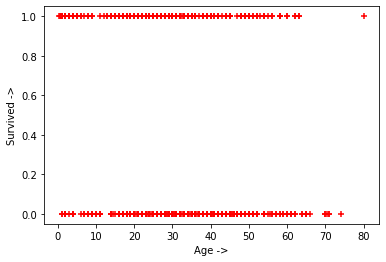

In [ ]:
plt.scatter(df.Age, df.Survived, marker='+', color='red')
plt.xlabel('Age ->')
plt.ylabel('Survived ->')

Text(0, 0.5, 'Survived ->')

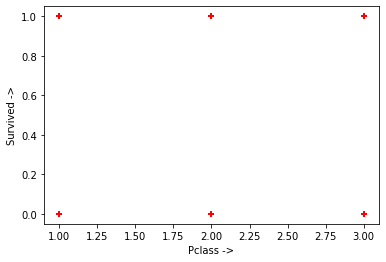

In [ ]:
plt.scatter(df.Pclass, df.Survived, marker='+', color='red')
plt.xlabel('Pclass ->')
plt.ylabel('Survived ->')

ValueError: ignored

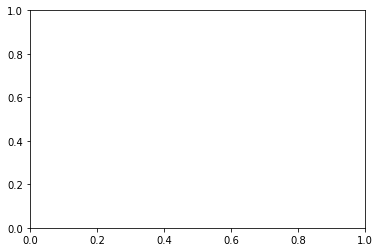

In [ ]:
plt.plot(df.Age,model.predict(X_test[0:10]),color='blue')
